<a href="https://colab.research.google.com/github/pawarisang258-2/SC663402_DW/blob/main/Part1_pawarisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [ ]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
# def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)

##setup

In [ ]:
# ----------------- Your code here -----------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import pandas as pd
import os

files = [
    "/content/drive/MyDrive/part1/posts_20241127_075347.jsonl",
    "/content/drive/MyDrive/part1/posts_20241127_075630.jsonl",
    "/content/drive/MyDrive/part1/posts_20241127_082640.jsonl"
]

for path in files:
    records = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))

    temp_df = pd.DataFrame(records)

    print("=" * 70)
    print("ไฟล์:", os.path.basename(path))
    print("จำนวนโพสต์:", len(temp_df))
    print("Fields:", temp_df.columns.tolist())

    if "created_at" in temp_df.columns:
        dates = pd.to_datetime(
            temp_df["created_at"],
            format="mixed",
            errors="coerce",
            utc=True
        )

        print("ช่วงวันที่โพสต์:")
        print(dates.min(), "ถึง", dates.max())

    print("\nตัวอย่างข้อความ:")
    display(temp_df[["text", "created_at"]].head(3))

ไฟล์: posts_20241127_075347.jsonl
จำนวนโพสต์: 6830
Fields: ['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']
ช่วงวันที่โพสต์:
2010-10-10 12:47:04+00:00 ถึง 2024-11-27 08:58:25.954000+00:00

ตัวอย่างข้อความ:


,text,created_at
0,This is really interesting polling data about ...,2024-11-27T07:53:47.202Z
1,"Niet been, iets.",2024-11-27T07:53:46.656Z
2,よく考えたらchrがsbさんの腰を両脚で挟んでどうこうとかポストしてたな\nいまさらだった……,2024-11-27T07:53:46.554Z


ไฟล์: posts_20241127_075630.jsonl
จำนวนโพสต์: 100000
Fields: ['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']
ช่วงวันที่โพสต์:
2008-05-04 18:27:34+00:00 ถึง 2024-11-30 10:50:04.343000+00:00

ตัวอย่างข้อความ:


,text,created_at
0,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...,2024-11-27T07:56:28.535Z
1,Lovely stuff.,2024-11-27T07:56:28.717Z
2,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다,2024-11-27T07:56:21.343Z


ไฟล์: posts_20241127_082640.jsonl
จำนวนโพสต์: 100000
Fields: ['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']
ช่วงวันที่โพสต์:
2008-04-29 03:33:45+00:00 ถึง 2024-11-28 08:38:12.998000+00:00

ตัวอย่างข้อความ:


,text,created_at
0,i need ao3 and funny people in my phone to get...,2024-11-27T08:26:37.406Z
1,Lmao i just saw this right after i made a skee...,2024-11-27T08:26:39.637Z
2,Someone just subscribed to my http://JustFor.F...,2024-09-13T10:48:04Z


รวม 3 ไฟล์

In [ ]:
# ============================================================
# Combine 3 JSONL files
# ============================================================

all_records = []

for path in files:
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            all_records.append(json.loads(line))

df = pd.DataFrame(all_records)

print("จำนวน records ทั้งหมด =", len(df))
print("จำนวน columns =", len(df.columns))
print("Columns:")
print(df.columns.tolist())

display(df.head())

จำนวน records ทั้งหมด = 206830
จำนวน columns = 6
Columns:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']


,text,created_at,author,uri,has_images,reply_to
0,This is really interesting polling data about ...,2024-11-27T07:53:47.202Z,did:plc:5ug6fzthlj6yyvftj3alekpj,at://did:plc:5ug6fzthlj6yyvftj3alekpj/app.bsky...,False,None
1,"Niet been, iets.",2024-11-27T07:53:46.656Z,did:plc:xfvxxrfblwuc3kdthl344vc5,at://did:plc:xfvxxrfblwuc3kdthl344vc5/app.bsky...,False,at://did:plc:fwjmfthdu5wppad75pcgpalj/app.bsky...
2,よく考えたらchrがsbさんの腰を両脚で挟んでどうこうとかポストしてたな\nいまさらだった……,2024-11-27T07:53:46.554Z,did:plc:33m5bavcbydbgxqv7lzukclo,at://did:plc:33m5bavcbydbgxqv7lzukclo/app.bsky...,False,None
3,#Br0kenColors\nThis was supposed to be the new...,2024-11-27T07:53:39.806Z,did:plc:ahpuzv6c3wvyjzttd67juzar,at://did:plc:ahpuzv6c3wvyjzttd67juzar/app.bsky...,True,None
4,Congratulations!,2024-11-27T07:53:47.131Z,did:plc:iasnzylah3rxqz2tiyhfusbl,at://did:plc:iasnzylah3rxqz2tiyhfusbl/app.bsky...,False,at://did:plc:lafbr3dznxdyvgup2umwssht/app.bsky...


Data Quality Check

In [ ]:
# ============================================================
# Initial Data Quality Check
# ============================================================

print("Missing Values:")
display(df.isna().sum())

print("\nDuplicate URI =", df["uri"].duplicated().sum())
print("Duplicate Text =", df["text"].duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:


,0
text,0
created_at,0
author,0
uri,0
has_images,0
reply_to,109808



Duplicate URI = 2
Duplicate Text = 14125

Data Types:
text          object
created_at    object
author        object
uri           object
has_images      bool
reply_to      object
dtype: object


clean

In [ ]:
# ============================================================
# Basic Cleaning
# ============================================================

df_clean = df.copy()

# ลบโพสต์ที่ URI ซ้ำ
df_clean = df_clean.drop_duplicates(subset=["uri"]).copy()

# แปลงเวลา
df_clean["created_at"] = pd.to_datetime(
    df_clean["created_at"],
    format="mixed",
    errors="coerce",
    utc=True
)

# จัดการข้อความ
df_clean["text"] = (
    df_clean["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# ตัดข้อความว่าง
df_clean = df_clean[df_clean["text"] != ""].copy()

df_clean = df_clean.reset_index(drop=True)

print("ก่อน clean =", len(df))
print("หลัง clean =", len(df_clean))
print("URI ซ้ำหลัง clean =", df_clean["uri"].duplicated().sum())
print("created_at ที่แปลงไม่ได้ =", df_clean["created_at"].isna().sum())
print("ข้อความว่าง =", (df_clean["text"] == "").sum())

ก่อน clean = 206830
หลัง clean = 200561
URI ซ้ำหลัง clean = 0
created_at ที่แปลงไม่ได้ = 0
ข้อความว่าง = 0


## Q1: คนโพสต์เมื่อไร

วิเคราะห์จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่มีการโพสต์มากที่สุดจากข้อมูล Bluesky

In [ ]:
# ============================================================
# Q1: Posting Time Analysis
# ============================================================

print("จำนวนโพสต์ทั้งหมด =", len(df_clean))

print("\nช่วงเวลาที่ข้อมูลครอบคลุม:")
print(df_clean["created_at"].min(), "ถึง", df_clean["created_at"].max())

df_clean["hour"] = df_clean["created_at"].dt.hour

hour_counts = (
    df_clean["hour"]
    .value_counts()
    .sort_index()
)

peak_hour = hour_counts.idxmax()
peak_count = hour_counts.max()

print(f"\nชั่วโมงที่มีโพสต์มากที่สุด = {peak_hour:02d}:00 UTC")
print("จำนวนโพสต์ =", peak_count)

display(hour_counts.rename("post_count").to_frame())

จำนวนโพสต์ทั้งหมด = 200561

ช่วงเวลาที่ข้อมูลครอบคลุม:
2008-04-29 03:33:45+00:00 ถึง 2024-11-30 10:50:04.343000+00:00

ชั่วโมงที่มีโพสต์มากที่สุด = 08:00 UTC
จำนวนโพสต์ = 165746


,post_count
hour,
0,713
1,629
2,574
3,516
4,428
5,558
6,490
7,16576
8,165746


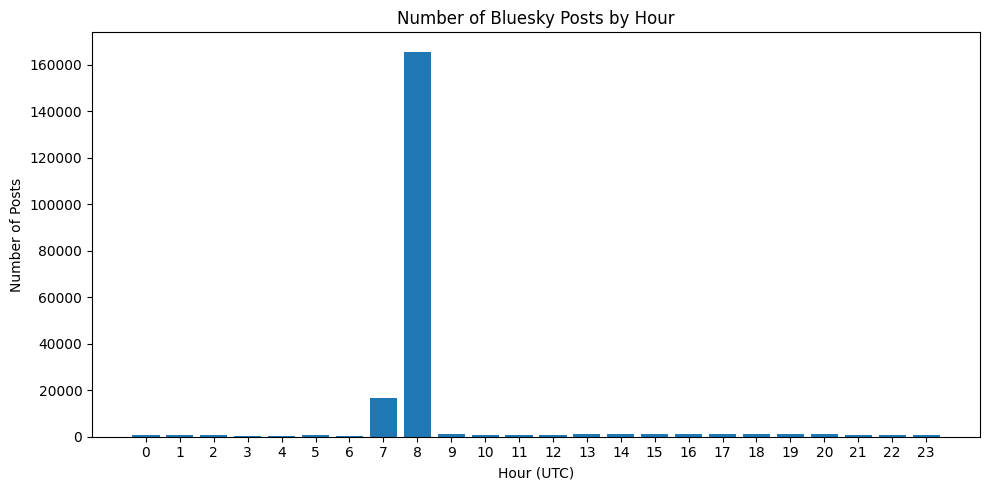

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(hour_counts.index, hour_counts.values)

plt.title("Number of Bluesky Posts by Hour")
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Posts")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

### สรุป Q1

จากข้อมูลที่นำมาวิเคราะห์ทั้งหมด 200,561 โพสต์ พบว่าข้อมูลครอบคลุมช่วงวันที่ 29 เมษายน 2008 ถึง 30 พฤศจิกายน 2024

ชั่วโมงที่มีจำนวนโพสต์มากที่สุดคือ 08:00 UTC จำนวน 165,746 โพสต์

จุดที่ต้องระวัง! จำนวนโพสต์ในช่วง 08:00 UTC กระจุกตัวสูงกว่าช่วงเวลาอื่นอย่างชัดเจน ดังนั้นผลนี้ควรตีความว่าเป็นลักษณะของชุดข้อมูลตัวอย่างที่เลือกมา และไม่ควรใช้สรุปพฤติกรรมของผู้ใช้ Bluesky ทั้งแพลตฟอร์ม

## Q2: ใช้ภาษาอะไร

วิเคราะห์ภาษาที่ใช้ในโพสต์ Bluesky เพื่อดูว่าภาษาใดเป็นภาษาหลัก และคำนวณสัดส่วนของแต่ละภาษาในชุดข้อมูล

In [ ]:
!pip -q install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 42

def detect_language(text):
    text = str(text).strip()

    # ข้อความสั้นมากตรวจภาษาได้ไม่แม่น
    if len(text) < 10:
        return "unknown"

    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df_clean["detected_language"] = df_clean["text"].apply(detect_language)

language_summary = (
    df_clean["detected_language"]
    .value_counts()
    .reset_index()
)

language_summary.columns = ["language", "count"]

language_summary["percentage"] = (
    language_summary["count"] / len(df_clean) * 100
).round(2)

display(language_summary.head(15))

,language,count,percentage
0,en,97614,48.67
1,ja,25542,12.74
2,unknown,15703,7.83
3,es,10021,5.00
4,de,8738,4.36
5,fr,6587,3.28
6,ko,6526,3.25
7,pt,2884,1.44
8,nl,2797,1.39
9,it,2236,1.11


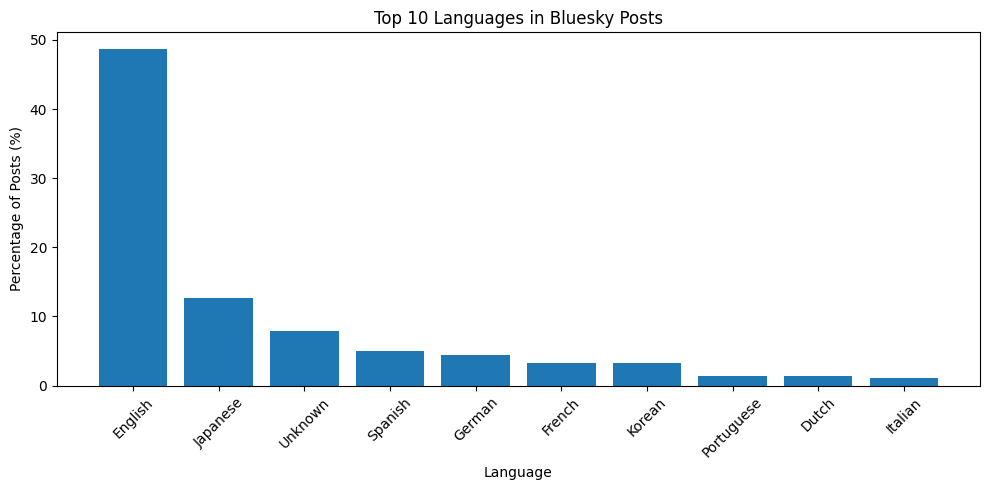

In [ ]:
# แปลงรหัสภาษาให้อ่านง่าย
language_names = {
    "en": "English",
    "ja": "Japanese",
    "es": "Spanish",
    "de": "German",
    "fr": "French",
    "ko": "Korean",
    "pt": "Portuguese",
    "nl": "Dutch",
    "it": "Italian",
    "tr": "Turkish",
    "unknown": "Unknown"
}

top10_lang = language_summary.head(10).copy()

top10_lang["language_name"] = (
    top10_lang["language"]
    .map(language_names)
    .fillna(top10_lang["language"])
)

plt.figure(figsize=(10, 5))

plt.bar(
    top10_lang["language_name"],
    top10_lang["percentage"]
)

plt.title("Top 10 Languages in Bluesky Posts")
plt.xlabel("Language")
plt.ylabel("Percentage of Posts (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### สรุป Q2

จากการตรวจภาษาของโพสต์ทั้งหมด 200,561 โพสต์ พบว่า English เป็นภาษาหลัก คิดเป็น 48.67% รองลงมาคือ Japanese 12.74% และ Spanish 5.00%

ดังนั้น หากต้องจัดทำคอนเทนต์จากกลุ่มข้อมูลนี้ ควรรองรับภาษาอังกฤษเป็นหลัก และอาจพิจารณาภาษาญี่ปุ่นและภาษาสเปนเป็นภาษารอง

จุดที่ต้องระวัง! มีข้อความประมาณ 7.83% ที่ไม่สามารถระบุภาษาได้ และการตรวจภาษาจากข้อความสั้นอาจมีความคลาดเคลื่อนได้

## Q3: คนพูดถึงอะไร

วิเคราะห์ Hashtag ที่ปรากฏบ่อยในโพสต์ เพื่อดูหัวข้อหรือประเด็นที่ถูกพูดถึงบ่อยในชุดข้อมูล และยกตัวอย่างข้อความจริงประกอบ

In [ ]:
# ============================================================
# Q3: Hashtag Analysis
# ============================================================

import re
from collections import Counter

def extract_hashtags(text):
    return re.findall(r"#\w+", str(text).lower())

all_hashtags = []

for text in df_clean["text"]:
    all_hashtags.extend(extract_hashtags(text))

hashtag_counts = Counter(all_hashtags)

hashtag_summary = pd.DataFrame(
    hashtag_counts.most_common(20),
    columns=["hashtag", "count"]
)

print("จำนวน Hashtag ทั้งหมด =", len(all_hashtags))
print("จำนวน Hashtag ที่ไม่ซ้ำ =", len(hashtag_counts))

display(hashtag_summary)

จำนวน Hashtag ทั้งหมด = 58528
จำนวน Hashtag ที่ไม่ซ้ำ = 26220


,hashtag,count
0,#art,530
1,#nsfw,356
2,#innovation,305
3,#booksky,249
4,#photography,239
5,#nowplaying,217
6,#books,191
7,#bookchallenge,175
8,#bluesky,155
9,#oc,155


,hashtag,count
0,#art,530
2,#innovation,305
3,#booksky,249
4,#photography,239
5,#nowplaying,217
6,#books,191
7,#bookchallenge,175
8,#bluesky,155
9,#oc,155
10,#ai,143


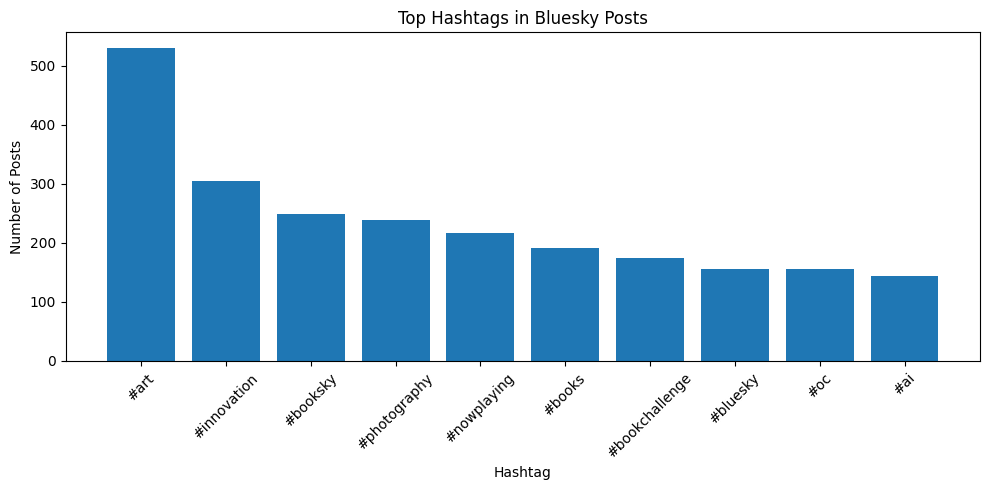

In [ ]:
# ============================================================
# Q3 Visualization: Top General Hashtags
# ============================================================

exclude_tags = {"#nsfw", "#porn", "#gay", "#nude"}

hashtag_general = hashtag_summary[
    ~hashtag_summary["hashtag"].isin(exclude_tags)
].head(10)

display(hashtag_general)

plt.figure(figsize=(10, 5))

plt.bar(
    hashtag_general["hashtag"],
    hashtag_general["count"]
)

plt.title("Top Hashtags in Bluesky Posts")
plt.xlabel("Hashtag")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

ตัวอย่างข้อมูลจริงประกอบ

In [ ]:
# ============================================================
# Example Posts for Selected Hashtags
# ============================================================

selected_tags = [
    "#art",
    "#innovation",
    "#booksky",
    "#photography",
    "#nowplaying"
]

for tag in selected_tags:
    examples = df_clean[
        df_clean["text"].str.contains(
            re.escape(tag),
            case=False,
            na=False
        )
    ]["text"].head(2)

    print("\n", "=" * 60)
    print(tag)

    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


#art
1. akihiko,,,, #artfromtheabyss #fatart #maleweightgain #bhm
2. outdoor studio today. #art #artsed

#innovation
1. In the AI race, slow and steady may just win the prize! Companies are eyeing 2025 with cautious optimism, balancing innovation with careful steps. The future is generative, but its all about the journey, not the sprint. #AI #Innovation #FutureTech https://tinyurl.com/29o959mu
2. The rise of the corporate #innovation unit — http://m.digitaljournal.com/business/business/op-ed-the-rise-of-the-corporate-innovation-unit/article/441079 by @PaulSloane

#booksky
1. Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers.

3/20

#BookSky💙📚
#Books
#BookChallenge
2. Choose 20 books that have stayed with you or influenced you. One book per day in no particular order. No explanations. No reviews. Just covers. #books #booksky💙📚 #bookchallenge

5: Together Is Better www.goodreads.com

### สรุป Q3

จากการวิเคราะห์ Hashtag พบว่า `#art` เป็น Hashtag ที่พบมากที่สุด จำนวน 530 ครั้ง รองลงมาคือ `#innovation` 305 ครั้ง, `#booksky` 249 ครั้ง และ `#photography` 239 ครั้ง

เมื่อพิจารณาข้อความจริงประกอบ พบว่า Hashtag เหล่านี้สะท้อนหัวข้อที่หลากหลาย เช่น งานศิลปะ เทคโนโลยีและนวัตกรรม หนังสือ การถ่ายภาพ และดนตรี

ตัวอย่างเช่น โพสต์ที่ใช้ `#booksky` กล่าวถึงการเลือกหนังสือที่มีอิทธิพลต่อผู้โพสต์ ขณะที่ `#photography` ใช้กับโพสต์เกี่ยวกับภาพถ่ายสถานที่และธรรมชาติ และ `#nowplaying` ใช้กับโพสต์เกี่ยวกับเพลงที่กำลังฟัง

ดังนั้น ในชุดข้อมูลนี้มีการพูดถึงหัวข้อด้านศิลปะ หนังสือ เทคโนโลยี การถ่ายภาพ และดนตรีค่อนข้างเด่น

## Q4: ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้

กราฟสัดส่วนภาษาหลักของโพสต์

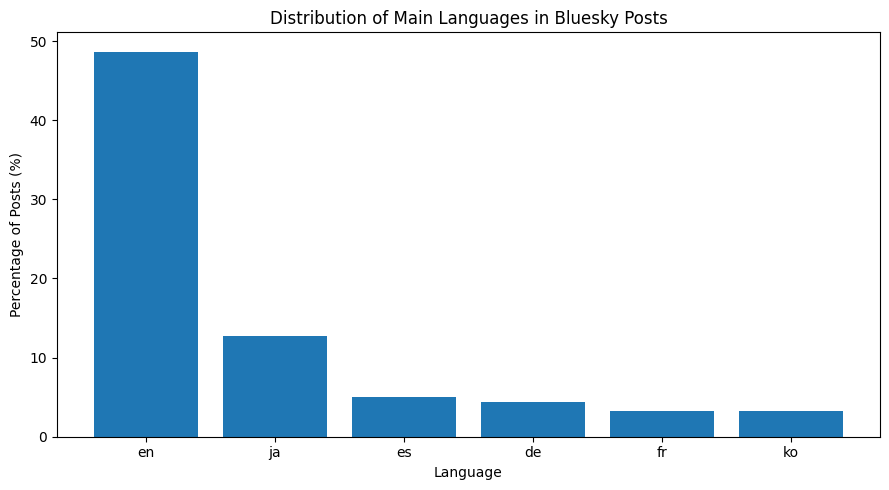

In [ ]:
# ============================================================
# Q4 Visualization: Language Distribution
# ============================================================

q4_lang = language_summary[
    language_summary["language"] != "unknown"
].head(6).copy()

plt.figure(figsize=(9, 5))

plt.bar(
    q4_lang["language"],
    q4_lang["percentage"]
)

plt.title("Distribution of Main Languages in Bluesky Posts")
plt.xlabel("Language")
plt.ylabel("Percentage of Posts (%)")

plt.tight_layout()
plt.show()

จากกราฟพบว่า English เป็นภาษาหลักของโพสต์ในชุดข้อมูลอย่างชัดเจน รองลงมาคือ Japanese, Spanish, German, French และ Korean และควรให้ความสำคัญกับภาษาอังกฤษเป็นหลัก

###สรุปQ4
#### ข้อมูลนี้บอกอะไรได้

ข้อมูลชุดนี้สามารถใช้ดูภาพรวมของโพสต์ในกลุ่มตัวอย่างที่เลือกมาได้ เช่น ช่วงเวลาที่มีการโพสต์มาก ภาษาที่ใช้บ่อย และหัวข้อหรือ Hashtag ที่ถูกพูดถึงบ่อย

#### ข้อมูลนี้บอกอะไรไม่ได้

ข้อมูลนี้ไม่สามารถใช้แทนพฤติกรรมของผู้ใช้ Bluesky ทั้งแพลตฟอร์มได้ เพราะใช้เพียง 3 ไฟล์จาก dataset ทั้งหมด

นอกจากนี้ สัดส่วนภาษาและหัวข้อที่พบสะท้อนเฉพาะข้อมูลที่เลือกมา และการตรวจภาษาจากข้อความสั้นหรือข้อความหลายภาษาอาจมีความคลาดเคลื่อนได้

จำนวนโพสต์หรือ Hashtag ที่พบมาก ยังไม่สามารถบอกได้โดยตรงว่าหัวข้อนั้นได้รับความนิยมมากที่สุด หรือผู้ใช้ทั้งหมดสนใจเรื่องนั้นมากที่สุด

#### ข้อจำกัด

- ข้อมูลที่ใช้มาจากเพียง 3 ไฟล์ จึงไม่สามารถใช้แทนผู้ใช้ Bluesky ทั้งแพลตฟอร์มได้
- การตรวจภาษาจากข้อความอาจคลาดเคลื่อนได้ โดยเฉพาะข้อความสั้นหรือข้อความหลายภาษา
- สัดส่วนภาษาที่พบสะท้อนเฉพาะชุดข้อมูลที่เลือกมา ไม่ได้หมายถึงสัดส่วนภาษาของ Bluesky ทั้งหมด
- ข้อมูลนี้ไม่ได้บอกจำนวนผู้ใช้จริงของแต่ละภาษา เพราะผู้ใช้หนึ่งคนอาจโพสต์หลายครั้งได้

**<สรุปสั้น ๆ ถึงลูกค้า 5 บรรทัด>**

* จากข้อมูลที่วิเคราะห์ พบว่าโพสต์ส่วนใหญ่กระจุกตัวอยู่ในช่วง 08:00 UTC
* ภาษาอังกฤษเป็นภาษาหลัก รองลงมาคือภาษาญี่ปุ่นและภาษาสเปน
* หัวข้อที่ถูกพูดถึงเด่น ได้แก่ งานศิลปะ นวัตกรรม หนังสือ การถ่ายภาพ และดนตรี
* หากต้องทำคอนเทนต์ ควรให้ความสำคัญกับภาษาอังกฤษเป็นหลัก และพิจารณาภาษาญี่ปุ่นเป็นภาษารอง
* ผลลัพธ์นี้เหมาะสำหรับใช้ดูแนวโน้มเบื้องต้นของเวลา ภาษา และหัวข้อที่ถูกพูดถึงในชุดข้อมูล